# YouTube Data Analysis

This notebook includes added comments to explain each step: loading data, sentiment analysis, emoji analysis, exporting data, SQLite export, and visualizations.


In [2]:
# Import pandas for reading and working with tabular data
import pandas as pd

# Read the YouTube comments CSV file.
# on_bad_lines="skip" skips broken rows that do not match the CSV structure.
df = pd.read_csv(
    r"C:\Users\emgha\Downloads\UScomments.csv",
    on_bad_lines="skip"
)

# Display the DataFrame to quickly check that the file loaded correctly
df


C:\Users\emgha\AppData\Local\Temp\ipykernel_7008\887740922.py:6: DtypeWarning: Columns (0: likes, 1: replies) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0
...,...,...,...,...
691395,EoejGgUNmVU,Лучшая,1,0
691396,EoejGgUNmVU,qu'est ce que j'aimerais que tu viennes à Roan...,0,0
691397,EoejGgUNmVU,Ven a mexico! 😍 te amo LP,0,0
691398,EoejGgUNmVU,Islığı yeter...,0,0


# **2. How to perform Sentiment Analysis**


In [3]:
# Install NLTK if it is not already installed
!pip install nltk


In [4]:
# Import the NLTK library
import nltk


In [5]:
# Download the VADER sentiment lexicon.
# VADER is useful for short social-media texts like YouTube comments.
nltk.download("vader_lexicon")

# Import and create the sentiment analyzer object
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\emgha\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [6]:
# This function receives one comment and returns its sentiment label and score.
def analyze_comment_sentiment(comment):
    # compound is the overall sentiment score from -1 (negative) to +1 (positive)
    compound = sia.polarity_scores(comment)['compound']

    # Classify the comment based on the compound score
    if compound > 0.05:
        label = 'positive :)'
    elif compound < -0.05:
        label = 'negative :('
    else:
        label = 'neutral :|'

    return {
        "label": label,
        "score": compound
    }


# **3. How to perform Emoji Analysis**


In [7]:
# Install emoji package if it is not already installed
!pip install emoji


In [8]:
# Import emoji package to detect emojis inside comments
import emoji

# This list will store all emojis found in comments
emoji_list = []

# dropna() removes missing comments before looping through them
for comment in df["comment_text"].dropna():
    # Check each character inside each comment
    for char in comment:
        # If the character is an emoji, save it in emoji_list
        if char in emoji.EMOJI_DATA:
            emoji_list.append(char)


In [9]:
# Show the first 10 emojis found in the comments
emoji_list[0:10]


['‼', '‼', '‼', '😉', '😭', '👍', '🏻', '❤', '😍', '💋']

In [10]:
# Analyze sentiment for every non-empty comment
label_score = []

for comment in df["comment_text"].dropna():
    label_score.append(analyze_comment_sentiment(comment))


In [11]:
# Preview the first 10 sentiment results
label_score[0:10]


[{'label': 'neutral :|', 'score': 0.0},
 {'label': 'neutral :|', 'score': 0.0},
 {'label': 'neutral :|', 'score': 0.0},
 {'label': 'positive :)', 'score': 0.4648},
 {'label': 'neutral :|', 'score': 0.0},
 {'label': 'neutral :|', 'score': 0.0},
 {'label': 'neutral :|', 'score': 0.0},
 {'label': 'neutral :|', 'score': 0.0},
 {'label': 'positive :)', 'score': 0.5719},
 {'label': 'negative :(', 'score': -0.7717}]

In [12]:
# Counter helps us count how many times each emoji appears
from collections import Counter

# Get the 10 most common emojis
emoji_count_list = Counter(emoji_list).most_common(10)

# Separate emojis and their counts for plotting
emojis = [emoji for emoji, count in emoji_count_list]
counts = [count for emoji, count in emoji_count_list]


In [13]:
# Install Plotly for interactive charts
!pip install plotly


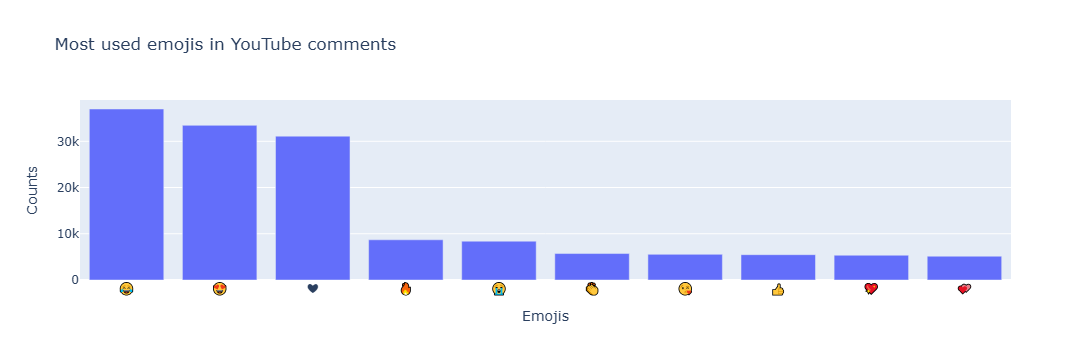

In [14]:
# Import Plotly Express for simple chart creation
import plotly.express as px

# Create a bar chart showing the most used emojis
fig = px.bar(
    x=emojis,
    y=counts,
    title="Most used emojis in YouTube comments",
    labels={
        "x": "Emojis",
        "y": "Counts"
    }
)

fig


In [15]:
# Set Plotly renderer for Jupyter Notebook display
import plotly.io as pio
pio.renderers.default = "iframe"

# Show the chart
fig.show()


# **4. Collect Entire Data of YouTube**


In [16]:
# os is used for working with folders and file paths
import os


In [17]:
# List all files inside the additional_data folder
files = os.listdir(r"C:\Users\emgha\Downloads\additional_data")


In [18]:
# Keep only CSV files from the folder
csv_file = [file for file in files if file.endswith(".csv")]


In [19]:
# Folder that contains all YouTube CSV files
path = r"C:\Users\emgha\Downloads\additional_data"

# Empty DataFrame where all CSV files will be combined
full_df = pd.DataFrame()

# Read each CSV file and add it to full_df
for file in csv_file:
    current_df = pd.read_csv(
        os.path.join(path, file),
        encoding='iso-8859-1',
        on_bad_lines='skip'
    )
    full_df = pd.concat([current_df, full_df], ignore_index=True)


In [20]:
# Check all column names in the combined DataFrame
full_df.columns


Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='str')

# **5. Export Your Data to CSV, JSON, and SQLite Database**


In [21]:
# Check how many duplicated rows exist before removing them
full_df[full_df.duplicated()].shape


(36417, 16)

In [22]:
# Remove duplicated rows from the dataset
full_df = full_df.drop_duplicates()


In [23]:
# Check the shape after removing duplicates
full_df.shape


(339525, 16)

In [24]:
# Create the export folder if it does not already exist
export_dir = r"C:\Users\emgha\Downloads\export_data"
os.makedirs(export_dir, exist_ok=True)

# Export the first 1000 rows to CSV
full_df[0:1000].to_csv(
    os.path.join(export_dir, "youtube_whole_data.csv"),
    index=False
)


In [25]:
# Export the first 1000 rows to JSON
full_df[0:1000].to_json(
    os.path.join(export_dir, "youtube_sample.json"),
    orient="records",
    indent=4
)


In [26]:
# Install SQLAlchemy to connect pandas with SQLite
!pip install sqlalchemy


In [27]:
# create_engine creates a connection engine for the SQLite database
from sqlalchemy import create_engine


In [28]:
# Build the SQLite file path using os.path.join
# This prevents path problems with / and \ on Windows.
db_path = os.path.join(export_dir, "youtube_data.sqlite")

# Create a SQLite engine. The file will be created after to_sql() runs.
engine = create_engine(f"sqlite:///{db_path}")

print(db_path)


C:\Users\emgha\Downloads\export_data\youtube_data.sqlite


In [29]:
# Save the full DataFrame into a SQLite table named "users".
# if_exists="replace" means: if the table already exists, overwrite it.
# index=False prevents pandas from saving the DataFrame index as an extra column.
full_df[0:1000].to_sql(
    "users",
    con=engine,
    if_exists="replace",
    index=False
)


1000

# **6. Which Category Dominates YouTube?**


In [30]:
# Check data types of all columns
full_df.dtypes


video_id                    str
trending_date               str
title                       str
channel_title               str
category_id               int64
publish_time                str
tags                        str
views                     int64
likes                     int64
dislikes                  int64
comment_count             int64
thumbnail_link              str
comments_disabled          bool
ratings_disabled           bool
video_error_or_removed     bool
description                 str
dtype: object

In [31]:
# Preview the trending_date column before converting it to datetime
full_df["trending_date"]


0         17.14.11
1         17.14.11
2         17.14.11
3         17.14.11
4         17.14.11
            ...   
375937    18.14.06
375938    18.14.06
375939    18.14.06
375940    18.14.06
375941    18.14.06
Name: trending_date, Length: 339525, dtype: str

In [32]:
# Convert trending_date from text to datetime format
full_df["trending_date"] = pd.to_datetime(
    full_df["trending_date"],
    format="%y.%d.%m"
)


In [33]:
# Load YouTube category mapping from JSON file
import json

path = r"C:\Users\emgha\Downloads\additional_data\us_category_id.json"

with open(path, 'r', encoding="utf_8") as f:
    data = json.load(f)


In [34]:
data

{'kind': 'youtube#videoCategoryListResponse',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJvJAAShlR6hM"',
 'items': [{'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKmPBggty2mZQ"',
   'id': '1',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Film & Animation',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/UZ1oLIIz2dxIhO45ZTFR3a3NyTA"',
   'id': '2',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Autos & Vehicles',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/nqRIq97-xe5XRZTxbknKFVe5Lmg"',
   'id': '10',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
    'title': 'Music',
    'assignable': True}},
  {'kind': 'youtube#videoCategory',
   'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/HwXKamM1Q20q9BN-oBJavSGkfDI"',
   'id': '15',
   'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdnt

In [35]:
data['items'][0]['snippet']['title']

'Film & Animation'

In [36]:
data['items'][0]['id']

'1'

In [37]:
# Create a dictionary that maps category_id to category title
cat_dict = {}

for item in data["items"]:
    cat_dict[int(item['id'])] = item['snippet']['title']


In [38]:
cat_dict

{1: 'Film & Animation',
 2: 'Autos & Vehicles',
 10: 'Music',
 15: 'Pets & Animals',
 17: 'Sports',
 18: 'Short Movies',
 19: 'Travel & Events',
 20: 'Gaming',
 21: 'Videoblogging',
 22: 'People & Blogs',
 23: 'Comedy',
 24: 'Entertainment',
 25: 'News & Politics',
 26: 'Howto & Style',
 27: 'Education',
 28: 'Science & Technology',
 29: 'Nonprofits & Activism',
 30: 'Movies',
 31: 'Anime/Animation',
 32: 'Action/Adventure',
 33: 'Classics',
 34: 'Comedy',
 35: 'Documentary',
 36: 'Drama',
 37: 'Family',
 38: 'Foreign',
 39: 'Horror',
 40: 'Sci-Fi/Fantasy',
 41: 'Thriller',
 42: 'Shorts',
 43: 'Shows',
 44: 'Trailers'}

In [39]:
full_df

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375937,sGolxsMSGfQ,2018-06-14,HOW2: How to Solve a Mystery,Annoying Orange,24,2018-06-13T18:00:07.000Z,"annoying orange|""funny""|""fruit""|""talking""|""ani...",80685,1701,99,1312,https://i.ytimg.com/vi/sGolxsMSGfQ/default.jpg,False,False,False,ð¨ NEW MERCH! http://amzn.to/annoyingorange ...
375938,8HNuRNi8t70,2018-06-14,Eli Lik Lik Episode 13 Partie 01,Elhiwar Ettounsi,24,2018-06-13T19:01:18.000Z,"hkayet tounsia|""elhiwar ettounsi""|""denya okhra...",103339,460,66,51,https://i.ytimg.com/vi/8HNuRNi8t70/default.jpg,False,False,False,âº Retrouvez vos programmes prÃ©fÃ©rÃ©s : htt...
375939,GWlKEM3m2EE,2018-06-14,KINGDOM HEARTS III â SQUARE ENIX E3 SHOWCASE...,Kingdom Hearts,20,2018-06-11T17:30:53.000Z,"Kingdom Hearts|""KH3""|""Kingdom Hearts 3""|""Froze...",773347,25900,224,3881,https://i.ytimg.com/vi/GWlKEM3m2EE/default.jpg,False,False,False,Find out more about Kingdom Hearts 3: https://...
375940,lbMKLzQ4cNQ,2018-06-14,Trump Advisor Grovels To Trudeau,The Young Turks,25,2018-06-13T04:00:05.000Z,"180612__TB02SorryExcuse|""News""|""Politics""|""The...",115225,2115,182,1672,https://i.ytimg.com/vi/lbMKLzQ4cNQ/default.jpg,False,False,False,Peter Navarro isnât talking so tough now. An...


In [40]:
# Add category_name column by mapping category_id to cat_dict
full_df["category_name"] = full_df["category_id"].map(cat_dict)


In [41]:
full_df

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...,Comedy
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375937,sGolxsMSGfQ,2018-06-14,HOW2: How to Solve a Mystery,Annoying Orange,24,2018-06-13T18:00:07.000Z,"annoying orange|""funny""|""fruit""|""talking""|""ani...",80685,1701,99,1312,https://i.ytimg.com/vi/sGolxsMSGfQ/default.jpg,False,False,False,ð¨ NEW MERCH! http://amzn.to/annoyingorange ...,Entertainment
375938,8HNuRNi8t70,2018-06-14,Eli Lik Lik Episode 13 Partie 01,Elhiwar Ettounsi,24,2018-06-13T19:01:18.000Z,"hkayet tounsia|""elhiwar ettounsi""|""denya okhra...",103339,460,66,51,https://i.ytimg.com/vi/8HNuRNi8t70/default.jpg,False,False,False,âº Retrouvez vos programmes prÃ©fÃ©rÃ©s : htt...,Entertainment
375939,GWlKEM3m2EE,2018-06-14,KINGDOM HEARTS III â SQUARE ENIX E3 SHOWCASE...,Kingdom Hearts,20,2018-06-11T17:30:53.000Z,"Kingdom Hearts|""KH3""|""Kingdom Hearts 3""|""Froze...",773347,25900,224,3881,https://i.ytimg.com/vi/GWlKEM3m2EE/default.jpg,False,False,False,Find out more about Kingdom Hearts 3: https://...,Gaming
375940,lbMKLzQ4cNQ,2018-06-14,Trump Advisor Grovels To Trudeau,The Young Turks,25,2018-06-13T04:00:05.000Z,"180612__TB02SorryExcuse|""News""|""Politics""|""The...",115225,2115,182,1672,https://i.ytimg.com/vi/lbMKLzQ4cNQ/default.jpg,False,False,False,Peter Navarro isnât talking so tough now. An...,News & Politics


In [42]:
# Sum total views by date and category
full_df.groupby(["trending_date", "category_name"])["views"].sum()


trending_date  category_name       
2017-11-14     Autos & Vehicles          5449767
               Comedy                   92798793
               Education                 8625525
               Entertainment           233134424
               Film & Animation         59824388
                                         ...    
2018-06-14     Pets & Animals           16508451
               Science & Technology     19655174
               Shows                     2986906
               Sports                   58612762
               Travel & Events           2320638
Name: views, Length: 3290, dtype: int64

In [43]:
# Convert grouped data into a pivot table.
# Rows are dates, columns are categories, and values are total views.
pivot_df = full_df.groupby(["trending_date", "category_name"])["views"].sum().unstack(fill_value=0)
pivot_df


category_name,Autos & Vehicles,Comedy,Education,Entertainment,Film & Animation,Gaming,Howto & Style,Movies,Music,News & Politics,Nonprofits & Activism,People & Blogs,Pets & Animals,Science & Technology,Shows,Sports,Trailers,Travel & Events
trending_date,,,,,,,,,,,,,,,,,,
2017-11-14,5449767,92798793,8625525,233134424,59824388,20788680,39692396,0,522096451,22893805,1397585,69741490,3427634,19628265,1689318,34161599,0,1424022
2017-11-15,8050486,89048129,7072457,200761218,73620337,18302875,47173790,0,363498984,19512569,5363406,68342887,1684139,44572576,2456621,40823955,0,1487868
2017-11-16,7358437,82066922,7296205,215075485,78182533,18411174,36334035,0,336201790,21519797,4584043,47542853,2609618,39281789,1019265,46353999,0,2066936
2017-11-17,6436997,81766773,9328728,231929119,50794195,10147876,34707221,0,357949721,25304189,1377828,48916714,2068139,48763394,2433230,41649023,0,1001796
2017-11-18,7098844,80400958,8837341,217196554,64075205,10738066,29769264,0,369823307,26600320,2859005,45943293,4302877,77863217,3520947,33424799,0,1487049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-06-10,3419469,92834235,7405034,541526503,120104266,70525231,63597826,0,1388065416,50320845,2267573,156067902,16377474,38192009,1764569,71436390,0,1855303
2018-06-11,4911969,93551035,10338600,505373442,119098102,74941508,62355833,0,1297630273,32512659,2739846,126699590,17112106,38183326,2122065,77764246,0,2108882
2018-06-12,5126438,109037786,9841181,482032248,135940594,108525939,54252824,0,943951258,35845162,3237080,128605502,15477174,30930795,2436709,57287168,0,2287951


In [44]:
# Create an area chart to compare category views over time
area_chart = px.area(
    data_frame=pivot_df,
    x=pivot_df.index,
    y=pivot_df.columns,
    title="Trending Momentum over time by category"
)


In [45]:
area_chart

In [46]:
# Select the top 6 categories by total views
top_categories = full_df.groupby(["category_name"])["views"].sum().nlargest(6).index
top_categories


Index(['Music', 'Entertainment', 'Film & Animation', 'People & Blogs',
       'Comedy', 'Sports'],
      dtype='str', name='category_name')

In [47]:
# Keep only the top categories in the pivot table
filter_df = pivot_df[top_categories]
filter_df


category_name,Music,Entertainment,Film & Animation,People & Blogs,Comedy,Sports
trending_date,,,,,,
2017-11-14,522096451,233134424,59824388,69741490,92798793,34161599
2017-11-15,363498984,200761218,73620337,68342887,89048129,40823955
2017-11-16,336201790,215075485,78182533,47542853,82066922,46353999
2017-11-17,357949721,231929119,50794195,48916714,81766773,41649023
2017-11-18,369823307,217196554,64075205,45943293,80400958,33424799
...,...,...,...,...,...,...
2018-06-10,1388065416,541526503,120104266,156067902,92834235,71436390
2018-06-11,1297630273,505373442,119098102,126699590,93551035,77764246
2018-06-12,943951258,482032248,135940594,128605502,109037786,57287168


In [48]:
# Create an area chart only for the top 6 categories
area_chart = px.area(
    data_frame=filter_df,
    x=filter_df.index,
    y=filter_df.columns,
    title="Trending Momentum over time by top 6 categories"
)

area_chart


# **7. Do Viral Videos Actually Get Engagement?**


In [49]:
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name'],
      dtype='str')

In [50]:
# Engagement rate shows how much interaction a video gets compared to its views
full_df['engagement_rate'] = (full_df['likes'] + full_df['comment_count']) / full_df['views']


In [51]:
# Use a sample to make the bubble chart faster and lighter
bubble_sample = full_df.sample(50000, random_state=42)


In [52]:
# Create a bubble chart:
# x = views, y = engagement rate, bubble size = comment count
bubble = px.scatter(
    bubble_sample,
    x='views',
    y='engagement_rate',
    size='comment_count',
    color='category_name',
    hover_name='title',
    title='Engagement Bubble Map: Views vs Engagement Rate',
    size_max=60
)


In [53]:
bubble

In [54]:
# Use logarithmic scale because views can have very large differences
bubble.update_xaxes(type='log')


# **8. Views vs Engagement: Inside YouTube Algorithm**


In [55]:
# Create summary metrics for each category
category_metric = full_df.groupby('category_name').agg(
    total_views=('views', 'sum'),
    avg_engagement_efficiency=('engagement_rate', 'mean'),
    video_count=('video_id', 'count')
).reset_index()


In [56]:
category_metric.columns

Index(['category_name', 'total_views', 'avg_engagement_efficiency',
       'video_count'],
      dtype='str')

In [57]:
category_metric.isna().sum()

category_name                0
total_views                  0
avg_engagement_efficiency    0
video_count                  0
dtype: int64

In [58]:
# Create a treemap to show total views and engagement efficiency by category
treemap = px.treemap(
    category_metric,
    path=['category_name'],
    values='total_views',
    color='avg_engagement_efficiency',
    color_continuous_scale='RdYlGn',
    title='Category Attention Share with Engagement Efficiency Overlay',
    hover_data={
        'total_views': ':,.0f',
        'avg_engagement_efficiency': ':.3f',
        'video_count': True
    }
)


In [59]:
treemap

# **9. Is the Audience Actually Engaged?**


In [60]:
# Summary statistics for engagement rate
full_df['engagement_rate'].describe()


count    339525.000000
mean          0.042103
std           0.043971
min           0.000000
25%           0.010395
50%           0.027453
75%           0.060261
max           0.957256
Name: engagement_rate, dtype: float64

In [61]:
# Compare engagement statistics between categories
category_engagement_stats = full_df.groupby('category_name')['engagement_rate'].describe()
category_engagement_stats.sort_values('mean', ascending=False)


,count,mean,std,min,25%,50%,75%,max
category_name,,,,,,,,
Howto & Style,17549.0,0.062121,0.042688,0.000000,0.032948,0.052991,0.082680,0.709778
Science & Technology,7350.0,0.058860,0.053710,0.000000,0.024923,0.047330,0.077522,0.774282
Comedy,24024.0,0.058413,0.046692,0.000000,0.022036,0.048903,0.082108,0.746056
Gaming,10433.0,0.057708,0.048587,0.000000,0.022935,0.048472,0.078039,0.863608
Education,7396.0,0.057669,0.042375,0.000000,0.028697,0.050298,0.077079,0.445312
Music,36990.0,0.051929,0.045435,0.000000,0.021012,0.038634,0.067957,0.506464
Pets & Animals,4215.0,0.050707,0.039806,0.000000,0.023875,0.040444,0.066759,0.330806
Autos & Vehicles,4596.0,0.049873,0.035542,0.000000,0.024870,0.045179,0.068422,0.234820
Nonprofits & Activism,2722.0,0.049619,0.058793,0.000000,0.009192,0.023070,0.074042,0.704366


In [62]:
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name',
       'engagement_rate'],
      dtype='str')

In [63]:
# Box plot shows the distribution of engagement rate by category
box = px.box(
    full_df,
    x='category_name',
    y='engagement_rate',
    color='category_name',
    title='Audience Engagement by Category'
)

box
